In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

import thermoift.PLOT_SETTINGS as ps

In [2]:
df1 = pd.read_csv("CSV_OLD/feed_2_interfacial_results.csv")
df2 = pd.read_csv("CSV_OLD/feed_3_interfacial_results.csv")
df3 = pd.read_csv("CSV_OLD/feed_4_interfacial_results.csv")
df4 = pd.read_csv("CSV_OLD/feed_5_interfacial_results.csv")
df5 = pd.read_csv("CSV_OLD/feed_6_interfacial_results.csv")
df6 = pd.read_csv("CSV_OLD/feed_7_interfacial_results.csv")
df7 = pd.read_csv("CSV_OLD/feed_8_interfacial_results.csv")
df8 = pd.read_csv("CSV_OLD/feed_9_interfacial_results.csv")

df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df = df.dropna(subset=["gamma"])
df.to_csv("CSV_OLD/interfacial_results_cleaned.csv", index=False)

In [3]:
target      = "gamma"
exclude     = ["temperature", "pressure", "interfacial_thickness", "E_carbon dioxide", "E_argon", "E_hydrogen", "vapor_density", "liquid_density",
                "P_dew", "z_carbon dioxide", "z_argon", "z_hydrogen"]

features    = [col for col in df.columns if col != target and col not in exclude]
print(features)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85)

print(f"Training: {X_train.shape[0]} rows")
print(f"Testing:  {X_test.shape[0]} rows")

['Tc', 'Pc', 'P_bubble', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon']
Training: 5757 rows
Testing:  1440 rows


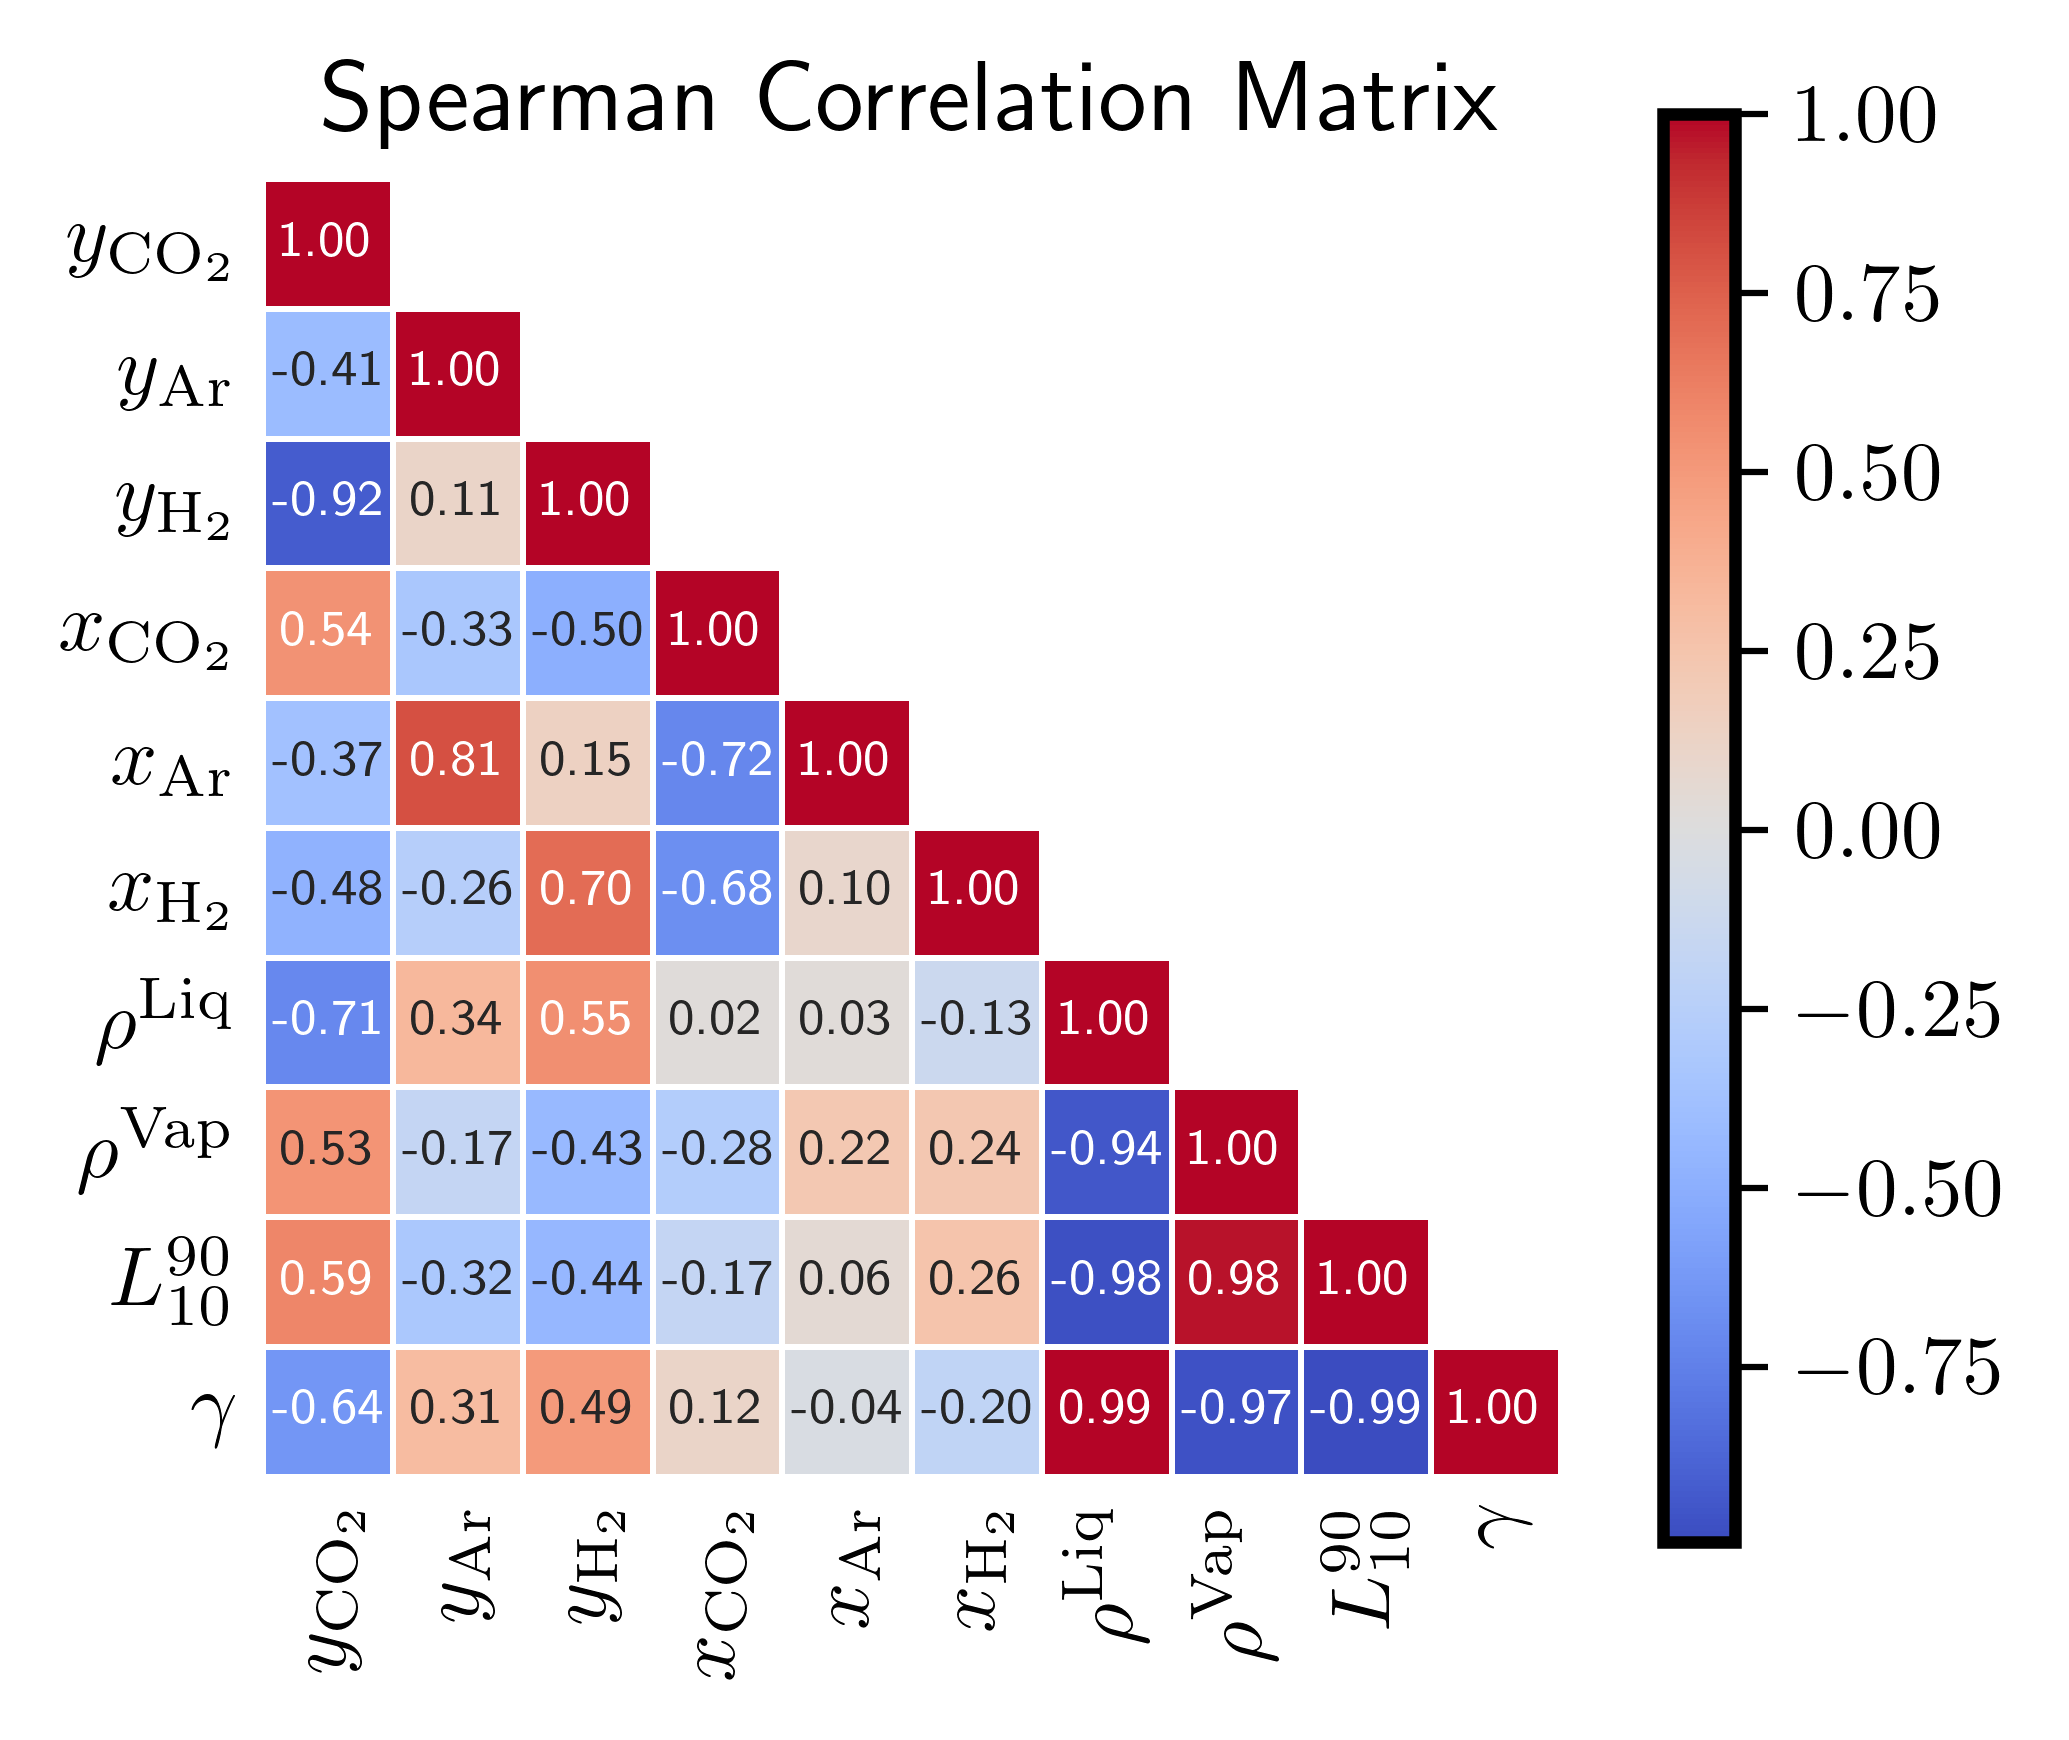

In [4]:
numeric_cols = [
                # "temperature", "pressure", 
                # "Tc", "Pc", 
                "y_carbon dioxide", "y_argon", "y_hydrogen",
                "x_carbon dioxide", "x_argon", "x_hydrogen",
                "liquid_density", "vapor_density",
                "interfacial_thickness", "gamma"]

label_map = {
    # "temperature"      : r"$T$",
    # "pressure"         : r"$P$",
    # "Tc"               : r"$T_c$",
    # "Pc"               : r"$P_c$",
    "y_carbon dioxide" : r"$y_{\mathrm{CO_2}}$",
    "y_argon"          : r"$y_{\mathrm{Ar}}$",
    "y_hydrogen"       : r"$y_{\mathrm{H_2}}$",
    "x_carbon dioxide" : r"$x_{\mathrm{CO_2}}$",
    "x_argon"          : r"$x_{\mathrm{Ar}}$",
    "x_hydrogen"       : r"$x_{\mathrm{H_2}}$",
    "liquid_density"   : r"$\rho^{\mathrm{Liq}}$",
    "vapor_density"    : r"$\rho^{\mathrm{Vap}}$",
    "interfacial_thickness": r"$L_{10}^{90}$",
    "gamma"            : r"$\gamma$"
}

corr = df[numeric_cols].corr(method="spearman")
corr = corr.rename(index=label_map, columns=label_map)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = ps.plot_init()

cm = sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap=ps.map,
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 6},
    cbar_kws={"shrink": 1.1}
)

cbar = cm.collections[0].colorbar
ps.style_colorbar(cbar)
ax.set_title("Spearman Correlation Matrix", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.tick_params(axis="both", length=0)

plt.tight_layout()
ps.save_plot(fig, "feed_1_correlation")
plt.show()

In [5]:
with plt.style.context(["ieee"]):
    plt.rcParams["font.family"] = ps.graphic_font
    plt.rcParams["mathtext.fontset"] = ps.math_font
    plt.rcParams["text.usetex"] = True

    # OPTIONAL: bump font sizes (only for this plot) without editing settings file
    ps.tick_labelsize = max(ps.tick_labelsize, 12)

    fig = plt.figure(figsize=(18, 20))
    fig.suptitle(r'Interfacial Tension Data — $\mathrm{CO_2/H_2/Ar}$ Ternary System (Feed 1)',
    fontsize=24, fontweight="bold", y=0.94)

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ────────────────── 1. gamma vs Temperature (colored by Pressure) ──────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    sc = ax1.scatter(df["temperature"], df["gamma"], c=df["pressure"], cmap=ps.map, s=15, alpha=0.7)
    cbar1 = plt.colorbar(sc, ax=ax1)
    cbar1.set_label(r"$P\, / \,[\mathrm{bar}]$", fontsize=ps.label_fontsize*1.5)
    ps.style_colorbar(cbar1)
    ax1.set_xlabel(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
    ax1.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    ax1.set_title(r"$\gamma$ vs $T$", fontsize=ps.title_fontsize*1.5, fontweight="bold")

    # ────────────────── 2. gamma vs Pressure (colored by Temperature) ──────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    sc2 = ax2.scatter(df["pressure"], df["gamma"], c=df["temperature"], cmap=ps.map, s=15, alpha=0.7)
    cbar2 = plt.colorbar(sc2, ax=ax2)
    cbar2.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
    ps.style_colorbar(cbar2)
    ax2.set_xlabel(r"$P\, / \, [\mathrm{bar}]$", fontsize=ps.label_fontsize*1.5)
    ax2.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    ax2.set_title(r"$\gamma$ vs $P$" "\n" r"(colored by $T$)", fontsize=ps.title_fontsize*1.5, fontweight="bold")

    # ────────────────── 3. Distribution of gamma ───────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(df["gamma"], bins=40, edgecolor="white", color="#8CCEEC", alpha=0.85)
    # ax3.axvline(df["gamma"].mean(), linestyle="--", label=rf"Mean: {df['gamma'].mean():.2f}")
    # ax3.axvline(df["gamma"].median(), linestyle="--", label=rf"Median: {df['gamma'].median():.2f}")
    ax3.set_xlabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    ax3.set_ylabel(r"Count / [-]", fontsize=ps.label_fontsize*1.5)
    ax3.set_title(r"Distribution of $\gamma$", fontsize=ps.title_fontsize*1.5, fontweight="bold")
    # ps.style_legend(ax3, fontsize=max(getattr(ps, "legend_fontsize", 10), 10))

    # ────────────────── 4. gamma vs Liquid Density ─────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    sc4 = ax4.scatter(df["liquid_density"], df["gamma"], c=df["temperature"], cmap=ps.map, s=15, alpha=0.7)
    cbar4 = plt.colorbar(sc4, ax=ax4)
    cbar4.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
    ps.style_colorbar(cbar4)
    ax4.set_xlabel(r"$\rho^{\mathrm{Liq}}\, / \, [\mathrm{kg\,m^{-3}}]$", fontsize=ps.label_fontsize*1.5)
    ax4.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    ax4.set_title(r"$\gamma$ vs $\rho^{\mathrm{Liq}}$", fontsize=ps.title_fontsize*1.5, fontweight="bold")

    # ────────────────── 5. gamma vs Vapor Density ──────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    sc5 = ax5.scatter(df["vapor_density"], df["gamma"], c=df["temperature"], cmap=ps.map, s=15, alpha=0.7)
    cbar5 = plt.colorbar(sc5, ax=ax5)
    cbar5.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
    ps.style_colorbar(cbar5)
    ax5.set_xlabel(r"$\rho^{\mathrm{Vap}}\, / \, [\mathrm{kg\,m^{-3}}]$", fontsize=ps.label_fontsize*1.5)
    ax5.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    ax5.set_title(r"$\gamma$ vs $\rho^{\mathrm{Vap}}$", fontsize=ps.title_fontsize*1.5, fontweight="bold")

    # ────────────────── 6. gamma vs Interfacial Thickness ──────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    sc6 = ax6.scatter(df["interfacial_thickness"], df["gamma"], c=df["temperature"], cmap=ps.map, s=15, alpha=0.7)
    cbar6 = plt.colorbar(sc6, ax=ax6)
    cbar6.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
    ps.style_colorbar(cbar6)
    ax6.set_xlabel(r"$L_{10}^{90}\, / \, [\mathrm{nm}]$", fontsize=ps.label_fontsize*1.5)
    ax6.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    # ax6.set_title(r"$\gamma$ vs $L_{10}^{90}$", fontsize=ps.title_fontsize*1.5, fontweight="bold")

    # ────────────────── 7. Correlation Heatmap ─────────────────────────────────
    ax7 = fig.add_subplot(gs[2, :2])
    numeric_cols = ["temperature", "pressure", "Tc", "Pc", "y_carbon dioxide", "y_argon",
        "x_carbon dioxide", "x_argon",
        "liquid_density", "vapor_density",
        "interfacial_thickness", "gamma"]
    
    label_map = {
    "y_carbon dioxide": r"$y_{\mathrm{CO_2}}$",
    "y_argon": r"$y_{\mathrm{Ar}}$",
    "liquid_density": r"$\rho^{\mathrm{Liq}}$",
    "vapor_density": r"$\rho^{\mathrm{Vap}}$",
    "interfacial_thickness": r"$L_{10}^{90}$",
    "gamma": r"$\gamma$"}
    
    corr = df[numeric_cols].corr(method="spearman")
    corr = corr.rename(index=label_map, columns=label_map)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    cm = sns.heatmap(
        corr,
        ax=ax7,
        annot=True,
        fmt=".2f",
        cmap=ps.map,
        center=0,
        mask=mask,
        square=True,
        linewidths=0.5,
        annot_kws={"size": 9},
        cbar_kws={"shrink": 0.8}
    )
    
    cbar7 = cm.collections[0].colorbar
    ps.style_colorbar(cbar7)
    ax7.set_title("Correlation Matrix", fontsize=ps.title_fontsize*1.5, fontweight="bold")

    # ────────────────── 8. gamma along Phase Envelope ──────────────────────────
    ax8 = fig.add_subplot(gs[2, 2])
    t_groups = df.groupby("temperature")["gamma"]
    t_vals = sorted(df["temperature"].unique())
    means = [t_groups.get_group(t).mean() for t in t_vals]
    mins  = [t_groups.get_group(t).min()  for t in t_vals]
    maxs  = [t_groups.get_group(t).max()  for t in t_vals]

    ax8.plot(t_vals, means, color='steelblue', linewidth=2)
    ax8.fill_between(t_vals, mins, maxs, alpha=0.2, color='steelblue', label=r"min-max range")
    ax8.set_xlabel(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
    ax8.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize*1.5)
    ax8.set_title(r"$\gamma$ along Phase Envelope" "\n" r"(mean $\pm$ range per $T$)",
        fontsize=ps.title_fontsize*1.5, fontweight="bold")
    
    ps.style_legend(ax8, fontsize=max(getattr(ps, "legend_fontsize", 10), 10))

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax8]:
        ps.apply_axis_style(ax)
        ax.minorticks_on()
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis="both", which="minor", length=3)
    
    for ax in [ax7]:
        ps.apply_axis_style(ax)   
        ax7.tick_params(axis="both", length=0)

    ps.save_plot(fig, f"feed_1_analysis")
    plt.show()

In [6]:
# ─────────────────────────────────────── ML──────────────────────────────────────────────

# Linear regression
lr = LinearRegression().fit(X_train, y_train)
print(f"Linear R²: {r2_score(y_test, lr.predict(X_test)):.4f}")
print(f"Linear RMSE:{np.sqrt(mean_squared_error(y_test, lr.predict(X_test))):.4f} mN/m")

coeff_lr = pd.DataFrame({
    'Feature':     ['intercept (b0)'] + features,
    'Coefficient': [lr.intercept_]    + list(lr.coef_)
}).sort_values('Coefficient', ascending=False)

print(coeff_lr.to_string(index=False))

# β₀ — the intercept (separate attribute)
print(f"Intercept (b0): {lr.intercept_:.4f}")
# Random forrest
rf = RandomForestRegressor(n_estimators=500, random_state=44505455)
rf.fit(X_train, y_train)
print(f"Random Forest R²: {r2_score(y_test, rf.predict(X_test)):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, rf.predict(X_test))):.4f} mN/m")

fi_rf = pd.DataFrame({
    'Feature':    features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

lr_pred       = lr.predict(X_test)
rf_pred       = rf.predict(X_test)
lr_residuals  = y_test.values - lr_pred
rf_residuals  = y_test.values - rf_pred
lr_r2         = r2_score(y_test, lr_pred)
rf_r2         = r2_score(y_test, rf_pred)
lr_rmse       = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_rmse       = np.sqrt(mean_squared_error(y_test, rf_pred))

Linear R²: 0.7915
Linear RMSE:2.2133 mN/m
         Feature  Coefficient
  intercept (b0) 10171.775037
x_carbon dioxide   146.324047
         y_argon    11.172917
              Pc     4.174371
      y_hydrogen     1.385302
        P_bubble     0.043621
y_carbon dioxide   -12.558219
      x_hydrogen   -20.484696
              Tc   -34.938425
         x_argon  -125.839351
Intercept (b0): 10171.7750


Random Forest R²: 0.9995
Random Forest RMSE: 0.1129 mN/m


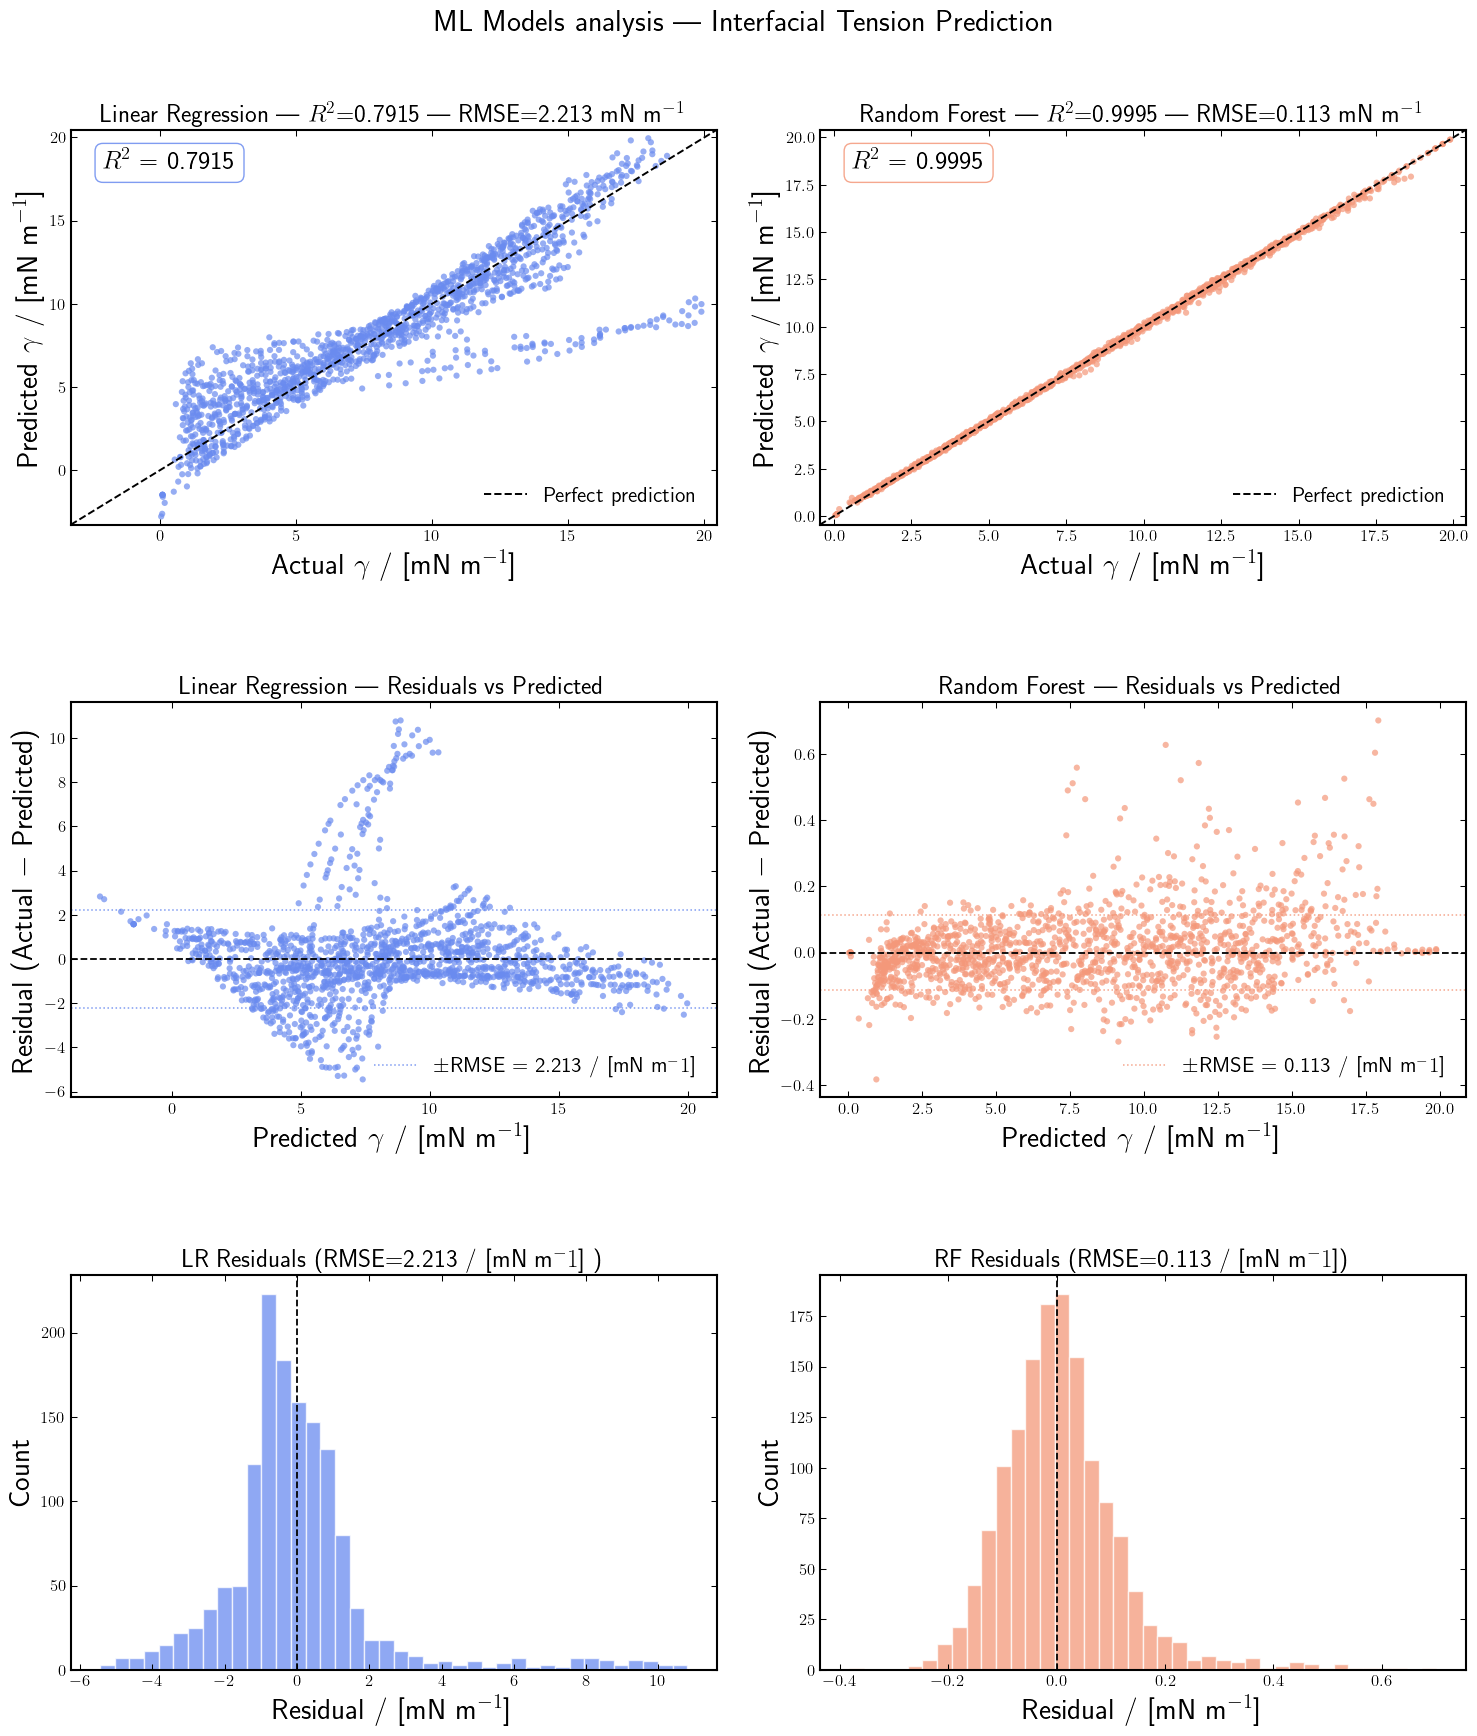

In [7]:
# ──────────────────── ML PLOTS ───────────────────────────
fig1 = plt.figure(figsize=(18, 20))
fig1.suptitle(r"ML Models analysis — Interfacial Tension Prediction",
               fontsize=ps.title_fontsize*1.8, fontweight="bold", y=0.94)

gs = gridspec.GridSpec(3, 4, figure=fig1, hspace=0.45, wspace=0.38)
lab_fs   = ps.label_fontsize*1.5
tit_fs   = ps.title_fontsize*1.5
tick_fs  = ps.tick_fontsize*1.2 if hasattr(ps, "tick_fontsize") else ps.label_fontsize*1.1

# Global colormap to pick two consistent colors (LR / RF)
cmap = plt.get_cmap(ps.map)
c_lr = cmap(0.15)
c_rf = cmap(0.75)

def _style_ax(ax):
    ax.tick_params(labelsize=tick_fs)
    ps.apply_axis_style(ax)

def _diag_limits(y_true, y_pred, pad=0.5):
    lo = min(y_true.min(), y_pred.min()) - pad
    hi = max(y_true.max(), y_pred.max()) + pad
    return [lo, hi]

# ── Plot 1: Linear Regression — Predicted vs Actual ──────────────────────────
ax1 = fig1.add_subplot(gs[0, 0:2])
lims = _diag_limits(y_test, lr_pred, pad=0.5)
ax1.scatter(y_test, lr_pred, alpha=0.7, s=20, color=c_lr, edgecolors="none")
ax1.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel(r"Actual $\gamma$ / [mN m$^{-1}$]", fontsize=lab_fs)
ax1.set_ylabel(r"Predicted $\gamma$ / [mN m$^{-1}$]", fontsize=lab_fs)
ax1.set_title(rf"Linear Regression  |  $R^2$={lr_r2:.4f}  |  RMSE={lr_rmse:.3f} mN m$^{{-1}}$",
              fontsize=tit_fs, fontweight="bold")
ax1.legend(fontsize=tick_fs, frameon=False)
ax1.text(0.05, 0.90, rf"$R^2$ = {lr_r2:.4f}",
         transform=ax1.transAxes, fontsize=lab_fs*0.9, color='k', fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=c_lr, alpha=0.85))
_style_ax(ax1)

# ── Plot 2: Random Forest — Predicted vs Actual ──────────────────────────────
ax2 = fig1.add_subplot(gs[0, 2:4])
lims = _diag_limits(y_test, rf_pred, pad=0.5)
ax2.scatter(y_test, rf_pred, alpha=0.7, s=20, color=c_rf, edgecolors="none")
ax2.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.set_xlabel(r"Actual $\gamma$ / [mN m$^{-1}$]", fontsize=lab_fs)
ax2.set_ylabel(r"Predicted $\gamma$ / [mN m$^{-1}$]", fontsize=lab_fs)
ax2.set_title(rf"Random Forest  |  $R^2$={rf_r2:.4f}  |  RMSE={rf_rmse:.3f} mN m$^{{-1}}$",
              fontsize=tit_fs, fontweight="bold")
ax2.legend(fontsize=tick_fs, frameon=False)
ax2.text(0.05, 0.90, rf"$R^2$ = {rf_r2:.4f}",
         transform=ax2.transAxes, fontsize=lab_fs*0.9, color='k', fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=c_rf, alpha=0.85))
_style_ax(ax2)

# ── Plot 3: Linear Regression — Residuals vs Predicted ───────────────────────
ax3 = fig1.add_subplot(gs[1, 0:2])
ax3.scatter(lr_pred, lr_residuals, alpha=0.7, s=20, color=c_lr, edgecolors="none")
ax3.axhline(0, color="black", linewidth=1.3, linestyle="--")
ax3.axhline( lr_rmse, color=c_lr, linewidth=1.1, linestyle=":", alpha=0.85, label=rf"$\pm$RMSE = {lr_rmse:.3f} / [mN m$^{-1}$] ")
ax3.axhline(-lr_rmse, color=c_lr, linewidth=1.1, linestyle=":", alpha=0.85)
ax3.set_xlabel(r"Predicted $\gamma$ / [mN m$^{-1}$]", fontsize=lab_fs)
ax3.set_ylabel(r"Residual (Actual − Predicted)", fontsize=lab_fs)
ax3.set_title(r"Linear Regression — Residuals vs Predicted", fontsize=tit_fs, fontweight="bold")
ax3.legend(fontsize=tick_fs, frameon=False)
_style_ax(ax3)

# ── Plot 4: Random Forest — Residuals vs Predicted ───────────────────────────
ax4 = fig1.add_subplot(gs[1, 2:4])
ax4.scatter(rf_pred, rf_residuals, alpha=0.7, s=20, color=c_rf, edgecolors="none")
ax4.axhline(0, color="black", linewidth=1.3, linestyle="--")
ax4.axhline( rf_rmse, color=c_rf, linewidth=1.1, linestyle=":", alpha=0.85, label=rf"$\pm$RMSE = {rf_rmse:.3f} / [mN m$^{-1}$]")
ax4.axhline(-rf_rmse, color=c_rf, linewidth=1.1, linestyle=":", alpha=0.85)
ax4.set_xlabel(r"Predicted $\gamma$ / [mN m$^{-1}$]", fontsize=lab_fs)
ax4.set_ylabel(r"Residual (Actual − Predicted)", fontsize=lab_fs)
ax4.set_title(r"Random Forest — Residuals vs Predicted", fontsize=tit_fs, fontweight="bold")
ax4.legend(fontsize=tick_fs, frameon=False)
_style_ax(ax4)

# ── Plot 5a: Residual Distribution — Linear Regression ───────────────────────
ax5_lr = fig1.add_subplot(gs[2, 0:2])
ax5_lr.hist(lr_residuals, bins=40, alpha=0.75, color=c_lr, edgecolor="white")
ax5_lr.axvline(0, color="black", linewidth=1.3, linestyle="--")
ax5_lr.set_xlabel(r"Residual / [mN m$^{-1}$]", fontsize=lab_fs)
ax5_lr.set_ylabel(r"Count", fontsize=lab_fs)
ax5_lr.set_title(rf"LR Residuals (RMSE={lr_rmse:.3f} / [mN m$^{-1}$] )", fontsize=tit_fs, fontweight="bold")
_style_ax(ax5_lr)

# ── Plot 5b: Residual Distribution — Random Forest ───────────────────────────
ax5_rf = fig1.add_subplot(gs[2, 2:4])
ax5_rf.hist(rf_residuals, bins=40, alpha=0.75, color=c_rf, edgecolor="white")
ax5_rf.axvline(0, color="black", linewidth=1.3, linestyle="--")
ax5_rf.set_xlabel(r"Residual / [mN m$^{-1}$]", fontsize=lab_fs)
ax5_rf.set_ylabel(r"Count", fontsize=lab_fs)
ax5_rf.set_title(rf"RF Residuals (RMSE={rf_rmse:.3f} / [mN m$^{-1}$])", fontsize=tit_fs, fontweight="bold")
_style_ax(ax5_rf)

# ── Save & show ──────────────────────────────────────────────────────────────
ps.save_plot(fig1, "ML_PLOTS")
plt.show()

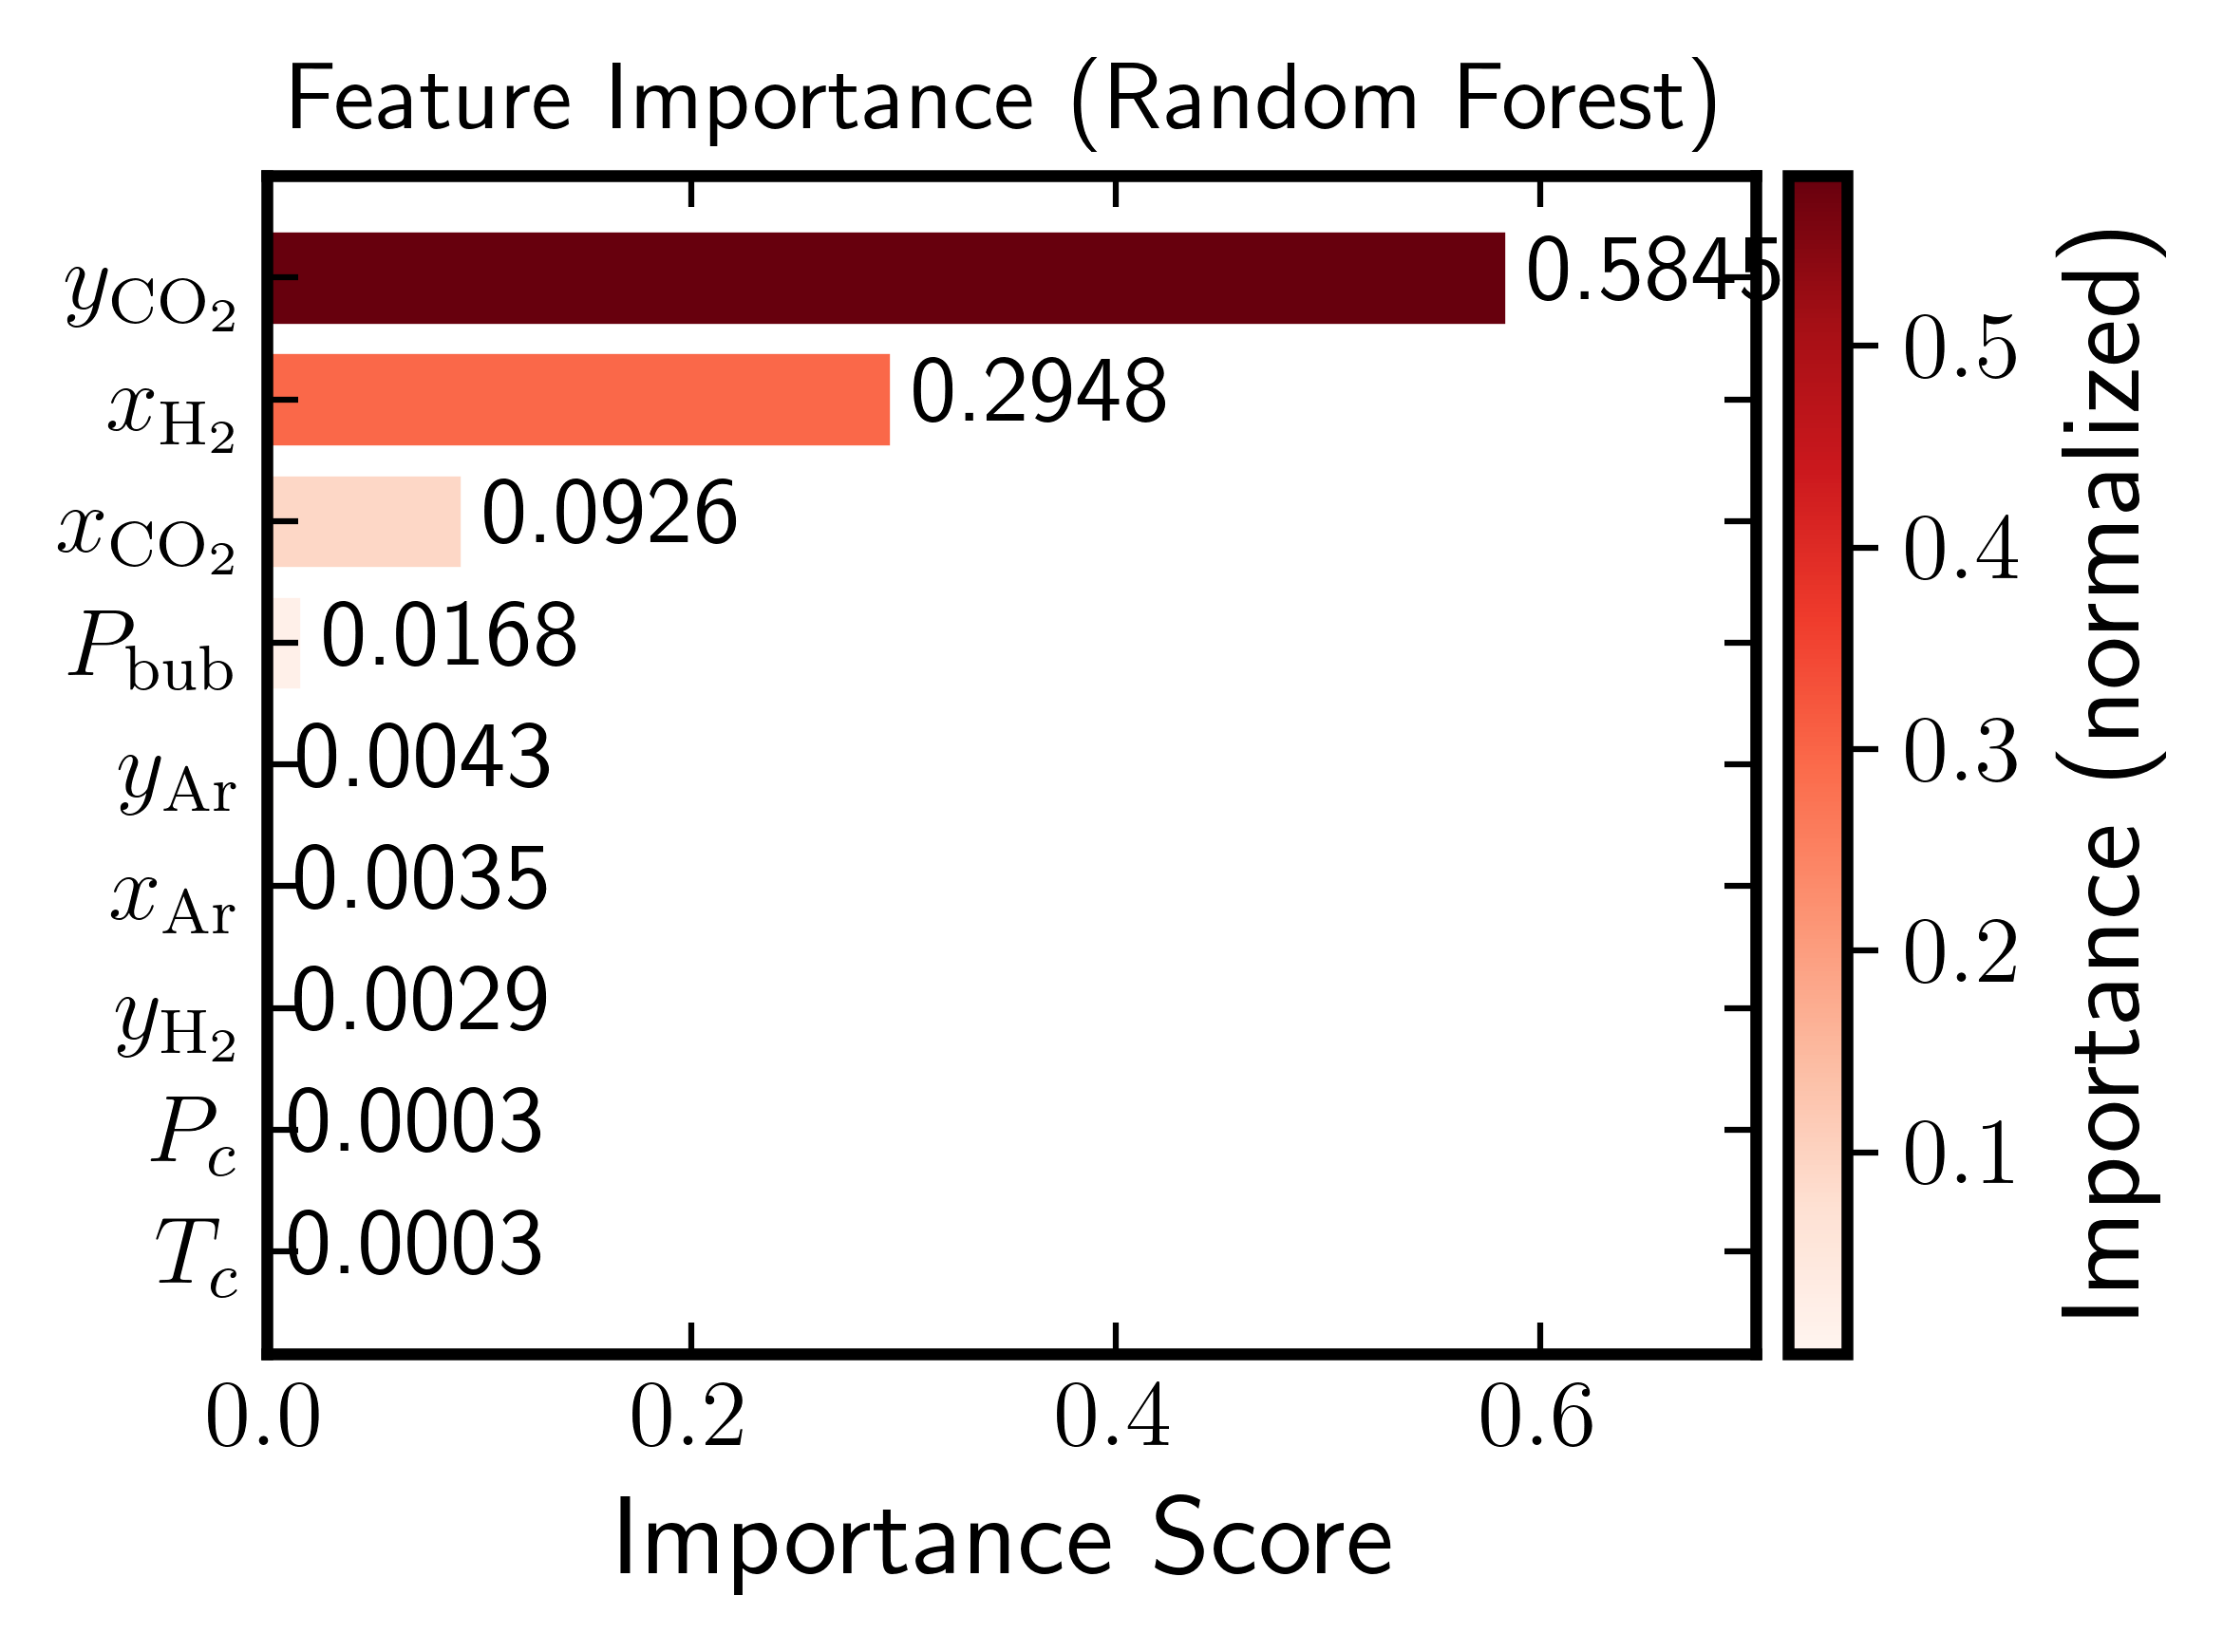

In [8]:
label_map = {
    "temperature"      : r"$T$",
    "pressure"         : r"$P$",
    "Tc"               : r"$T_c$",
    "Pc"               : r"$P_c$",
    "P_bubble"         : r"$P_{\mathrm{bub}}$",
    "P_dew"            : r"$P_{\mathrm{dew}}$",
    "z_carbon dioxide" : r"$z_{\mathrm{CO_2}}$",
    "z_argon"          : r"$z_{\mathrm{Ar}}$",
    "z_hydrogen"       : r"$z_{\mathrm{H_2}}$",
    "x_carbon dioxide" : r"$x_{\mathrm{CO_2}}$",
    "x_argon"          : r"$x_{\mathrm{Ar}}$",
    "x_hydrogen"       : r"$x_{\mathrm{H_2}}$",
    "y_carbon dioxide" : r"$y_{\mathrm{CO_2}}$",
    "y_argon"          : r"$y_{\mathrm{Ar}}$",
    "y_hydrogen"       : r"$y_{\mathrm{H_2}}$",
    "liquid_density"   : r"$\rho^{\mathrm{Liq}}$",
    "vapor_density"    : r"$\rho^{\mathrm{Vap}}$",
    "interfacial_thickness": r"$L_{10}^{90}$",
    "gamma"            : r"$\gamma$"
}

fig_imp, ax_imp = ps.plot_init()

importances = rf.feature_importances_
indices     = np.argsort(importances)
feat_names  = [label_map.get(features[i], features[i]) for i in indices]

cmap       = plt.get_cmap("Reds")
norm       = plt.Normalize(importances.min(), importances.max())
bar_colors = cmap(norm(importances[indices]))

bars = ax_imp.barh(feat_names, importances[indices], color=bar_colors, edgecolor="white", linewidth=0.8)

ax_imp.set_xlabel("Importance Score", fontsize=ps.label_fontsize)
ax_imp.set_title("Feature Importance (Random Forest)", fontsize=ps.title_fontsize, fontweight="bold")

for bar, val in zip(bars, importances[indices]):
    ax_imp.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", ha="left",
                fontsize=ps.label_fontsize * 0.85)

ax_imp.set_xlim(0, importances.max() * 1.2)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar_imp = plt.colorbar(sm, ax=ax_imp, fraction=0.05, pad=0.02)
cbar_imp.set_label("Importance (normalized)", fontsize=ps.label_fontsize)
ps.style_colorbar(cbar_imp)
ps.apply_axis_style(ax_imp)
plt.tight_layout()
# ps.save_plot(fig_imp, "RF_feature_importance")
plt.show()